Name: Moiz Sabir
Net ID: mas1050

Final Project: Pokemon Type Prediction Model based on Base Stat Distribution

As far as data clean up theres a couple things that have to be done first:

1. Some Pokemon in this dataset are of different forms. I'll refer to these forms as "gimmicks" - This will include "Mega" Pokemon, Pokemon of different regions (Alolan / Galarian) and other "Modes" (Zen-Mode / Therian / Piroette / Shield / Blade / Sizes / etc). The list of these Gimmicks are extensive and become increasingly common from the Unova Region so we will do a couple things to limit and clean up the dataset to use true normal base pokemons.

   a. Remove All Pokemon after 493 (Arceus) - Limit the dataset to Generations I-IV

    b. Any Pokemon Name which has the keyword "Mega" will be removed from the dataset.

   c. Similarly, any Pokemon name which contains a "-" (signifying some form) will be removed from the dataset.

   d. Any Pokemon with Multiple Words in their name (ie Wormadam Plant Cloak or Deoxys Normal Form) will be removed from the dataset by looking for " " characters in the name column.


      Performing this data cleaning in this order will ensure the proper removal of 99% of unwanted entries. An alternative method to remove these is to remove all duplicate Pokedex # entries by keeping the first one. I'll Attempt that first and then move to implement a-d to ensure the data is clean.

2. I'll also be removing all columns from P onwards as they dont provide any useful information or directly contribute to the type

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('pkmnData.csv')
df.head()


,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,...,Against Bug,Against Rock,Against Ghost,Against Dragon,Against Dark,Against Steel,Against Fairy,Height,Weight,BMI
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.7,6.9,14.1
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,13.0,13.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.0,100.0,25.0
3,3,Mega Venusaur,Grass,Poison,['Thick Fat'],80,100,123,122,120,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.4,155.5,27.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,...,0.5,2.0,1.0,1.0,1.0,0.5,0.5,0.6,8.5,23.6


In [2]:
#Lets drop col P onwards (index 15)

df = df.iloc[:, :15]
print(df.shape)
df.head()

(1032, 15)


,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,Spe,BST,Mean,Standard Deviation,Generation
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,45,318,53.000000,8.640988,1.0
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,60,405,67.500000,8.902247,1.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,80,525,87.500000,8.902247,1.0
3,3,Mega Venusaur,Grass,Poison,['Thick Fat'],80,100,123,122,120,80,625,104.166667,18.747592,6.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,65,309,51.500000,8.995369,1.0


In [3]:
#Remove duplicates based on '#', keeping the first occurrence
df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors='coerce')
df = df.drop_duplicates(subset=df.columns[0], keep='first')

print(df.shape)
df.head()

(898, 15)


,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,Spe,BST,Mean,Standard Deviation,Generation
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,45,318,53.0,8.640988,1.0
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,60,405,67.5,8.902247,1.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,80,525,87.5,8.902247,1.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,65,309,51.5,8.995369,1.0
5,5,Charmeleon,Fire,NaN,"['Blaze', 'Solar Power']",58,64,58,80,65,80,405,67.5,9.233093,1.0


Great - This removed Mega Venusaur as expected.

In [4]:
#Rule A: Keep only Pokémon up to Dex #493 (Arceus)
df = df[df.iloc[:, 0] <= 493]

#Rule B: Remove Pokémon with 'Mega' in the Name
df = df[~df.iloc[:, 1].str.contains('Mega', na=False)]

#Rule C: Remove Pokémon whose name contains a '-' (indicating forms)
df = df[~df.iloc[:, 1].str.contains('-', na=False)]

#Rule D: Remove Pokémon whose name contains a space ' ' (indicating forms)
df = df[~df.iloc[:, 1].str.contains(' ', na=False)]

#Final cleaned data shape
print(df.shape)
df.head()

(486, 15)


,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,Spe,BST,Mean,Standard Deviation,Generation
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,45,318,53.0,8.640988,1.0
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,60,405,67.5,8.902247,1.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,80,525,87.5,8.902247,1.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,65,309,51.5,8.995369,1.0
5,5,Charmeleon,Fire,NaN,"['Blaze', 'Solar Power']",58,64,58,80,65,80,405,67.5,9.233093,1.0


So this defnitely did remove a couple extra pokemon - For example Mr. Mime is effected by this, but a very good retention rate overall so we'll continue forward with it. Lets set the columns to their labels instead of indexes now.

In [5]:
df.columns = [
    'Number', 'Name', 'Type1', 'Type2', 'Abilities',
    'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'BST', 
    'Mean', 'Std', 'Gen'
]

In [6]:
#save cleaned dataset to new file
df.to_csv('pkmnData_cleaned.csv', index=False)

Now that we have our data set, lets start the fun part :)


In [7]:
#Load cleaned data
df = pd.read_csv('pkmnData_cleaned.csv')

#Keep only the stat columns for features
feature_cols = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']
X = df[feature_cols]

#We'll use Type 1 as the primary label to predict
y_type1 = df['Type1']
y_type2 = df['Type2']

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [9]:
#Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_type1, test_size=0.2, random_state=42)

#Create and train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Make predictions
y_pred = rf.predict(X_test)

#Evaluate performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Bug       0.50      0.50      0.50         6
        Dark       0.00      0.00      0.00         1
      Dragon       0.00      0.00      0.00         2
    Electric       0.17      0.25      0.20         4
    Fighting       0.00      0.00      0.00         3
        Fire       0.33      0.33      0.33         6
       Ghost       0.50      0.25      0.33         4
       Grass       0.00      0.00      0.00        12
      Ground       0.40      0.29      0.33         7
         Ice       0.00      0.00      0.00         1
      Normal       0.26      0.54      0.35        13
      Poison       0.00      0.00      0.00         5
     Psychic       0.25      0.20      0.22         5
        Rock       0.20      0.12      0.15         8
       Steel       0.00      0.00      0.00         3
       Water       0.23      0.28      0.25        18

    accuracy                           0.23        98
   macro avg       0.18   

/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


AAAND it would clearly seem theres way too little data. 

Since we've established that we can sufficiently clean the data, lets just keep all pokemon generations instead of limiting to Gen IV and go from there.



In [10]:
df = pd.read_csv('pkmnData.csv')
df.head()
df = df.iloc[:, :15]

df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors='coerce')
df = df.drop_duplicates(subset=df.columns[0], keep='first')

print(df.shape)
df.head()

#Rule A: Keep only Pokémon up to Dex #493 (Arceus)
#df = df[df.iloc[:, 0] <= 493]

#Rule B: Remove Pokémon with 'Mega' in the Name
df = df[~df.iloc[:, 1].str.contains('Mega', na=False)]

#Rule C: Remove Pokémon whose name contains a '-' (indicating forms)
df = df[~df.iloc[:, 1].str.contains('-', na=False)]

#Rule D: Remove Pokémon whose name contains a space ' ' (indicating forms)
df = df[~df.iloc[:, 1].str.contains(' ', na=False)]

df.columns = [
    'Number', 'Name', 'Type1', 'Type2', 'Abilities',
    'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'BST', 
    'Mean', 'Std', 'Gen'
]

#save cleaned dataset to new file
df.to_csv('allPkmnData_cleaned.csv', index=False)

#Load cleaned data
df = pd.read_csv('allPkmnData_cleaned.csv')

#Keep only the stat columns for features
feature_cols = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']
X = df[feature_cols]

#We'll use Type 1 as the primary label to predict
y_type1 = df['Type1']
y_type2 = df['Type2']

(898, 15)


Lets try running the training again:

In [11]:
#Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_type1, test_size=0.2, random_state=42)

#Create and train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Make predictions
y_pred = rf.predict(X_test)

# Evaluate performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Bug       0.26      0.38      0.31        13
        Dark       0.00      0.00      0.00         6
      Dragon       0.00      0.00      0.00         3
    Electric       0.12      0.12      0.12         8
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         5
        Fire       0.13      0.18      0.15        11
      Flying       0.00      0.00      0.00         3
       Ghost       0.00      0.00      0.00         4
       Grass       0.20      0.38      0.26        13
      Ground       0.14      0.14      0.14         7
         Ice       0.00      0.00      0.00         6
      Normal       0.36      0.42      0.38        24
      Poison       0.33      0.09      0.14        11
     Psychic       0.00      0.00      0.00         8
        Rock       0.11      0.08      0.10        12
       Steel       1.00      0.14      0.25         7
       Water       0.26    

/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Still doesnt look great honestly. Lets try swtiching the labeling Strategy to predict either type 1 or type 2 than a single correct answer

In [12]:
#Get prediction probabilities
probs = rf.predict_proba(X)
classes = rf.classes_

#Get top 2 predicted types per row
top2_idx = np.argsort(probs, axis=1)[:, -2:]  # indices of top 2
top2_preds = np.array([classes[row[::-1]] for row in top2_idx])  # top-1, top-2

#Add predictions to DataFrame
df['Guess 1'] = top2_preds[:, 0]
df['Guess 2'] = top2_preds[:, 1]

# Match checking function
def match_result(g1, g2, t1, t2):
    if g1 == t1: return 'Match Type 1'
    elif g1 == t2: return 'Match Type 2'
    elif g2 == t1: return 'Second Match Type 1'
    elif g2 == t2: return 'Second Match Type 2'
    else: return 'No Match'

#Apply custom logic
df['Match Result'] = df.apply(lambda row: match_result(row['Guess 1'], row['Guess 2'], row['Type1'], row['Type2']), axis=1)

#Count how well it did
df['Match Result'].value_counts()

Match Result
Match Type 1           729
No Match               107
Second Match Type 1     25
Match Type 2            10
Second Match Type 2      4
Name: count, dtype: int64

Wait this is actually promissing


In [13]:
cols_to_keep = [
    'Number', 'Name', 'Type1', 'Type2', 'HP', 'Attack', 'Defense', 
    'SpAtk', 'SpDef', 'Speed', 'Guess 1', 'Guess 2', 'Match Result'
]

#Create a new DataFrame for export
df_predicted = df[cols_to_keep]

#Save to CSV
df_predicted.to_csv('predictedAllPkmnData.csv', index=False)

Alrighty now manually inspecting the No Match Data gives some interesting insights:

1. Some Pokemon who got No Match have abnormally great stats that are common in other Typings. For example, Rapidash has a very high Speed stat, which is commonly attributed to Electric types (contributing to its initial Electric type guessing)
2. Most Commonly a Water type was predicted for pokemon where it was a missed match - and Water type is the primary typing for 14% of all pokemon in the dataset.
3. Visually Speaking it looks like the later generations are subject to less matches - lets try this: 

In [14]:
def assign_generation(num):
    if num <= 151:
        return 'Gen 1'
    elif num <= 251:
        return 'Gen 2'
    elif num <= 386:
        return 'Gen 3'
    elif num <= 493:
        return 'Gen 4'
    elif num <= 649:
        return 'Gen 5'
    elif num <= 721:
        return 'Gen 6'
    elif num <= 809:
        return 'Gen 7'
    elif num <= 905:
        return 'Gen 8'
    else:
        return 'Gen 9'

df['Generation'] = df['Number'].apply(assign_generation)

In [15]:
#Get just the No Matches
no_match_df = df[df['Match Result'] == 'No Match']

#No Match Counts by Generation
no_match_by_gen = no_match_df['Generation'].value_counts().sort_index()
total_by_gen = df['Generation'].value_counts().sort_index()

#Put into a comparison DataFrame
gen_comparison = pd.DataFrame({
    'No Match Count': no_match_by_gen,
    'Total Pokémon': total_by_gen
})
gen_comparison['No Match %'] = (gen_comparison['No Match Count'] / gen_comparison['Total Pokémon']) * 100

gen_comparison

,No Match Count,Total Pokémon,No Match %
Generation,,,
Gen 1,19,150,12.666667
Gen 2,8,98,8.163265
Gen 3,17,134,12.686567
Gen 4,12,104,11.538462
Gen 5,18,156,11.538462
Gen 6,8,68,11.764706
Gen 7,11,78,14.102564
Gen 8,14,87,16.091954


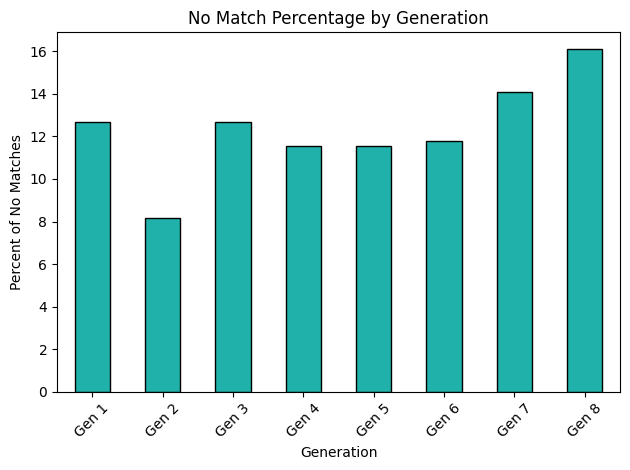

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

gen_comparison['No Match %'].plot(kind='bar', color='lightseagreen', edgecolor='black')
plt.title('No Match Percentage by Generation')
plt.ylabel('Percent of No Matches')
plt.xlabel('Generation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Overall, with the exception of a couple outliars it does seem like as the generations progress there are more No Matches.

Lets get some data visualtization for the model in general:

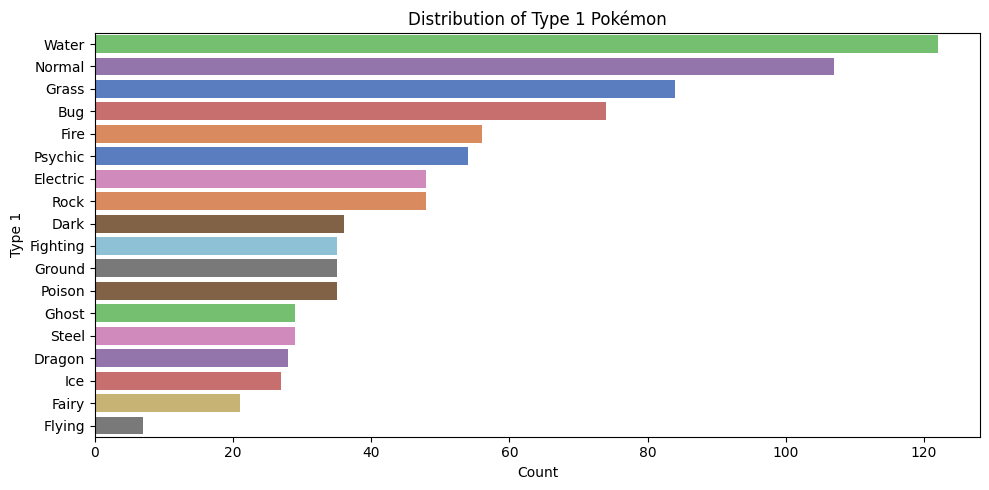

In [17]:
#Type Distribution of Type 1

plt.figure(figsize=(10, 5))
sns.countplot(y='Type1', data=df, order=df['Type1'].value_counts().index, palette='muted', hue='Type1')
plt.title('Distribution of Type 1 Pokémon')
plt.xlabel('Count')
plt.ylabel('Type 1')
plt.tight_layout()
plt.show()

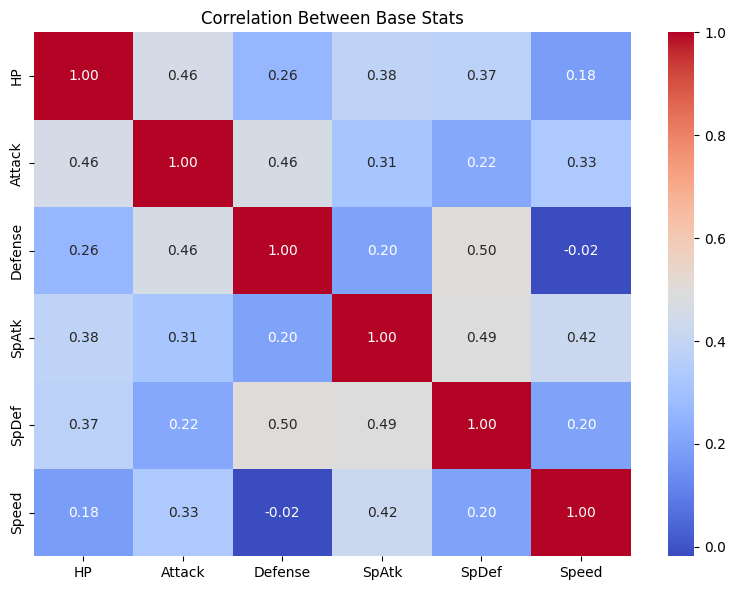

In [18]:
#Correlation Heatmap of Base Stats
plt.figure(figsize=(8, 6))
sns.heatmap(df[['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Base Stats')
plt.tight_layout()
plt.show()

In [ ]:
#Get top 8 most frequent Type 1 values
top_8_types = df['Type1'].value_counts().nlargest(8).index.tolist()

#Filter dataset to only those types
df_top_types = df[df['Type1'].isin(top_8_types)]

#Base stats to visualize
stat_cols = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']

#Create a boxplot for each stat
for stat in stat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Type1', y=stat, data=df_top_types, palette='Set3', hue='Type1')
    plt.title(f'{stat} Distribution Among Top 8 Pokémon Types')
    plt.xlabel('Type 1')
    plt.ylabel(stat)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Normal Types tend to have more HP contributing to about 50% missed matches
Rock Types tend to have more Attack and especially Defense (all 4 rock type guess 1 mismatches)
High SpAtk/SpDef is attributed to psychic types (80% missed matches)
High Speed is attributed to electric types (80% missed matches)


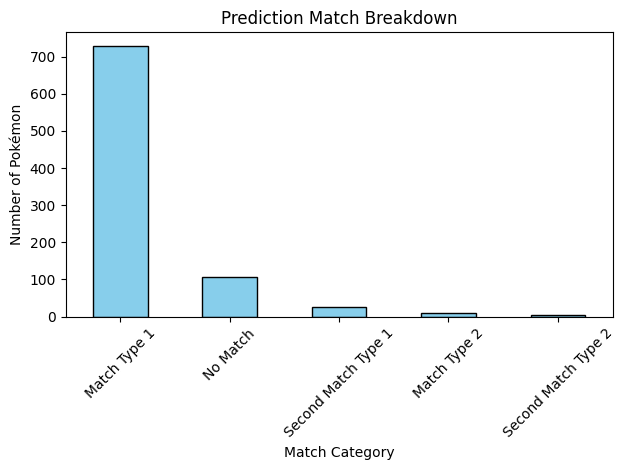

In [20]:
df['Match Result'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Prediction Match Breakdown')
plt.xlabel('Match Category')
plt.ylabel('Number of Pokémon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

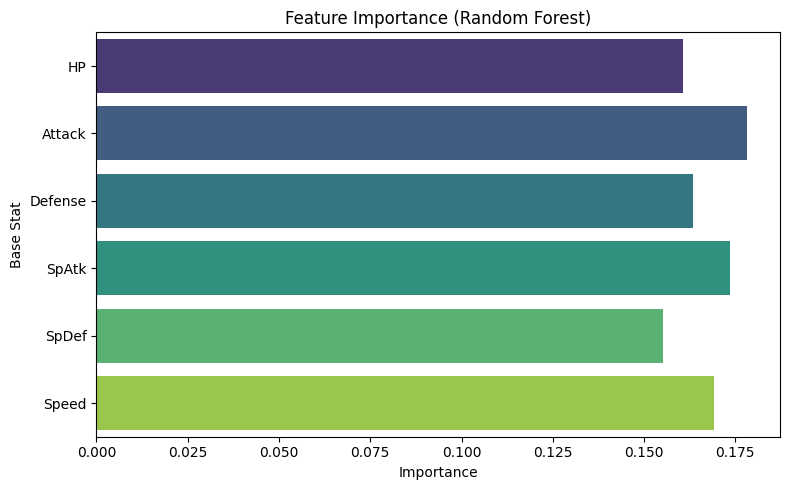

In [21]:
# Feature importance
importances = rf.feature_importances_
feature_names = ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed']

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis', hue=feature_names)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Base Stat')
plt.tight_layout()
plt.show()

1. Feature Importance (Random Forest Classifier)
The most important base stats for predicting a Pokémon’s type were:

    Attack

    Sp. Atk

    Speed

Slightly less important but still valuable:

    HP

    Sp. Def

    Defense

Offensive stats (especially Attack and Speed) are more useful for type classification than defensive ones.


2. Prediction Match Breakdown
    Match Type 1: Majority of predictions were accurate on the first guess (~83%).

    Match Type 2 / Second Match: Very few predictions landed on the secondary type.

    No Match: About 12% of Pokémon had no match within the top 2 predictions.

The model strongly learns primary type identities but struggles with secondary types or mixed-type Pokémon.


3. Correlation Between Base Stats
Moderate correlations observed between:

    Attack & Defense: 0.46

    Sp. Atk & Sp. Def: ~0.49

Low correlations between:

    Speed & All other stats

Speed is an independent trait, and most stats don’t overlap heavily, making all six useful features for modeling.


4. No Match Percentage by Generation
    Lowest no match rate: Gen 2 (~8%)

    Highest no match rate: Gen 8 (~16%)

    Most other generations fell between 11–13%

Newer generations (especially Gen 8) are harder for the model to predict, possibly due to more complex typings or stat distributions.


5. Boxplots – Stat Distributions Across Top 8 Types

   HP:
   
       -Normal and Water types show high variability and upper outliers.

       -Bug and Electric types tend to have lower HP.

____________________________________________
   Attack:

       -Rock, Fire, and Bug types show higher Attack values.

       -Psychic and Electric types have lower Attack overall.

____________________________________________
    Defense:
   
        -Rock types dominate in Defense.

        -Fire, Grass, and Electric types have lower Defensive stats.

____________________________________________
    Sp. Atk:

        -Psychic and Electric types have the highest Sp. Atk distributions.

        -Bug and Normal types lag behind.

____________________________________________
    Sp. Def:
   
        -Psychic and Water types are strong in Special Defense.

        -Grass, Bug, and Electric types are generally lower.
____________________________________________
    Speed:

        -Electric and Psychic types are among the fastest.

        -Rock and Grass types tend to be slower.

Stat identity aligns well with traditional type design (e.g., Rock = tanky, Psychic = fast special attackers, Electric = fast and offensive).

